In [1]:
from typing import List, TypedDict,Literal
from pydantic import BaseModel,Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import  StateGraph, START,END
from dotenv import load_dotenv

load_dotenv()

e:\Machine Learning and Data Science\Advanced-RAGS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs = (
    PyPDFLoader("documents/Company_Policies.pdf").load()
    + PyPDFLoader("documents/Company_Profile.pdf").load()
    + PyPDFLoader("documents/Product_and_Pricing.pdf").load()
)

#### Chunking

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=150).split_documents(docs)

### Embedding and Retriever

In [4]:
embeddings = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')
vector_store = FAISS.from_documents(chunks,embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k":1})

### LLM 

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

## Graph State

In [6]:
class State(TypedDict):

    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs : List[Document]
    context :str
    answer :str

    issup : Literal["fully_supported","partially_supported","no_support"]

    evidence: List[str]

    retries: int

    isuse : Literal["userful","not_useful"]

    use_reason : str

    retrieval_query: str
    rewrite_tries: int

### Decide Retrieval

In [7]:
class RetrieveDecision(BaseModel):

    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human","Question: {question}")
    ]
)

decide_retrieval_chain = decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision)


def decide_retrieval(state:State):
    out = decide_retrieval_chain.invoke({'question':state['question']})

    return {"need_retrieval": out.should_retrieve}

### Generate Direct Node

In [8]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your knowledge"
        ),
        ("human","{question}")
    ]
)

def generate_direct(state: State):

    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state['question']
        )
    )

    return {"answer": out.content}

### Retriver

In [9]:
def retrieve(state: State):
    q = state.get("retrieval_query") or state.get("question")
    return {'docs': retriever.invoke(q)}

### Is Relevant Node

In [10]:
class RelevanceDecision(BaseModel):
    is_relevant : bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

is_relevant_chain = is_relevant_prompt | llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):

    relevant_docs : List[Document] = []

    for doc in state['docs']:

        out = is_relevant_chain.invoke({'question':state['question'],'document':doc.page_content})

        if out.is_relevant:
            relevant_docs.append(doc)

    return {'relevant_docs':relevant_docs}

### Generate From Context

In [11]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG Assistant\n"
            "Answer the user question using only the provided context"
        ),
        (
            "human",
            "Question:\n{question}\n"
            "Context:\n{context}"
        ),
    ]
)

def generate_from_context(state: State):

    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs",[])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.","context":""}
    
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state['question'],
            context=context
        )
    )

    return {"answer": out.content,"context":context}

### No relevant Node

In [12]:
def no_relevant_docs(state: State):
    return  {"answer": "No relevant document found.","context":""}

#### Route 1

In [13]:
def route_after_decide(state: State):

    if state['need_retrieval']:
        return 'retrieve'
    return 'generate_direct'

#### Route 2

In [14]:
def route_after_relevance(state: State):
    if state.get('relevant_docs') and len(state['relevant_docs']) > 0:
        return 'generate_from_context'
    return "no_relevant_docs"

### Is Supported and Loop

In [15]:
class IsSuPDecision(BaseModel):
    issup: Literal["fully_supported","partially_supported","no_support"]
    evidence : List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Check if ANSWER is supported by CONTEXT.\n"
            "Return JSON: issup (fully_supported | partially_supported | no_support), evidence.\n\n"
            "- fully_supported: all claims directly in CONTEXT, no added wording.\n"
            "- partially_supported: facts match but includes any added interpretation/qualitative words.\n"
            "- no_support: key claims unsupported.\n\n"
            "Rules: be strict; any added wording ⇒ partially_supported; mostly unsupported ⇒ no_support; evidence ≤3 exact quotes; no outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        )
    ]
)

issup_chain = issup_prompt | llm.with_structured_output(IsSuPDecision)

def is_sup(state: State):
    out = issup_chain.invoke({"question":state['question'],"answer":state.get("answer",""),"context":state.get("context","")})

    return {"issup": out.issup,"evidence":out.evidence}

### Route 3 AFter is Supported

In [16]:
MAX_RETRIES = 2

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

### Revise Answer Loop

In [17]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

### IS Use Node

In [18]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_chain = isuse_prompt | llm.with_structured_output(IsUSEDecision)

def is_use(state: State):

    out = isuse_chain.invoke({"question":state['question'],"answer":state.get('answer',"")})

    return {"isuse": out.isuse, "use_reason": out.reason}




## Rewrite Question

In [19]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs. within 8 words\n\n"
            # "Rules:\n"
            # "- Keep it short (6–16 words).\n"
            # "- Preserve key entities (e.g., NexaAI, plan names).\n"
            # "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            # "- Remove filler words.\n"
            # "- Do NOT answer the question.\n"
            # "- Output JSON with key: retrieval_query\n\n"
            # "Examples:\n"
            # "Q: 'Do NexaAI plans include a free trial?'\n"
            # "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            # "Q: 'What is NexaAI refund policy?'\n"
            # "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)



rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # ✅ optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

### Route 4

In [20]:
MAX_REWRITE_TRIES = 2
def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

## Graph Build

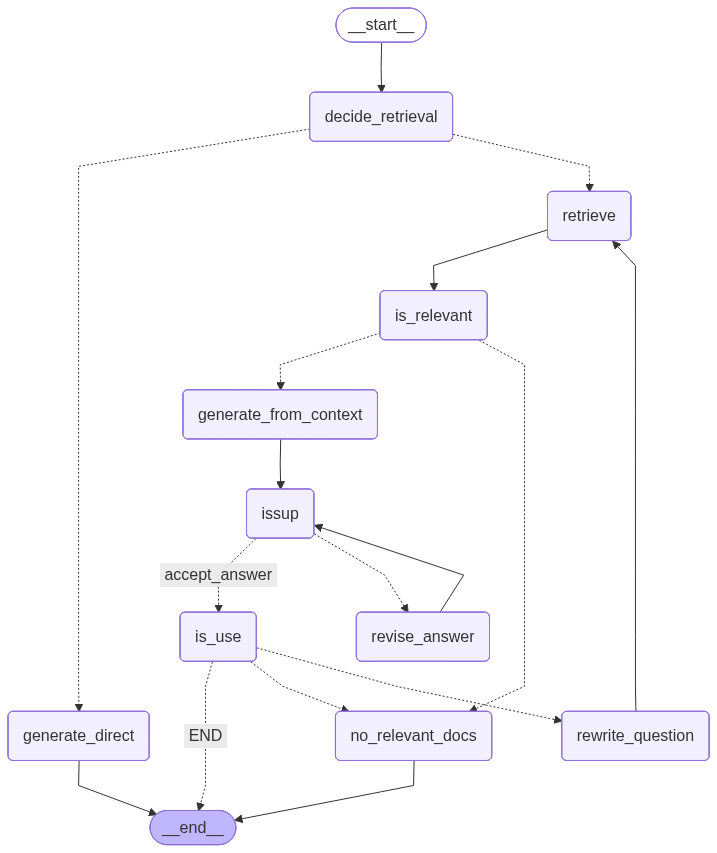

In [21]:
g = StateGraph(State)

g.add_node("decide_retrieval",decide_retrieval)
g.add_node("generate_direct",generate_direct)
g.add_node("retrieve",retrieve)
g.add_node("is_relevant",is_relevant)
g.add_node("generate_from_context",generate_from_context)
g.add_node("no_relevant_docs",no_relevant_docs)
g.add_node("issup",is_sup)
g.add_node("revise_answer",revise_answer)
g.add_node("is_use",is_use)

# new node
g.add_node("rewrite_question",rewrite_question)

g.add_edge(START,'decide_retrieval')

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct":"generate_direct",
        "retrieve":"retrieve"
    }
)


g.add_edge("generate_direct",END)

g.add_edge("retrieve","is_relevant")
g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context":"generate_from_context",
        "no_relevant_docs":"no_relevant_docs"

    }
)


g.add_edge("generate_from_context","issup")
g.add_conditional_edges(
    "issup",
    route_after_issup,
    {"accept_answer":"is_use","revise_answer":"revise_answer"}
    )

g.add_edge("revise_answer","issup")

g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {"END":END,"no_relevant_docs":"no_relevant_docs","rewrite_question":"rewrite_question"}

)

g.add_edge("rewrite_question","retrieve")


g.add_edge("no_relevant_docs",END)

app = g.compile()

app

In [22]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Describe NexaAI’s company culture.",
    "retrieval_query": "",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: Describe NexaAI’s company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 0

Retrieval:
  Total retrieved docs: 1
  Relevant docs: 1

Relevant docs (source/page):
  1. source=documents/Company_Policies.pdf, page=0, title=(anonymous)

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
   - All employment decisions are made without discrimination.
   - Employees are encouraged to maintain a healthy work-life balance.

Usefulness (IsUSE):
  isuse: useful
  reason: The answer directly addresses the question by describing NexaAI's company culture.

Final Answer:
NexaAI is committed to fostering a fair, inclusive, and performance-driven workplace where all employment decisions are made without discrimination, adhering to equal opportunity principles. The company also emphasizes a healthy work-life balance for its em